In [ ]:
%pip install pyarrow torch

In [ ]:
%pip install umap-learn scikit-learn

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import numpy as np
import pandas as pd
from pathlib import Path

OUT_DIR = Path("/content/drive/MyDrive/tag-polysemy/clap-embeddings")
BASE = "clap_music_htsat"                # base name without extension
MAIN_F = OUT_DIR / f"{BASE}.parquet"     # the first existing file

parts = [MAIN_F] + sorted(OUT_DIR.glob(f"{BASE}.append_*.parquet"))
dataset = ds.dataset(parts, format="parquet")
tbl = dataset.to_table()
df = tbl.to_pandas() # columns: path (str), track_id (int), embedding (list[float32] len=512)
E = np.vstack(df["embedding"].to_numpy())
ids = df["track_id"].to_numpy()
paths = df["path"].to_numpy()
print(E.shape, len(paths))


(55701, 512) 55701


In [ ]:
# L2-normalize rows (safe default for CLAP-like embeddings)
E = E.astype(np.float32, copy=False)
row_norms = np.linalg.norm(E, axis=1, keepdims=True) + 1e-8
E_unit = E / row_norms

OUT_DIR = Path("/content/drive/MyDrive/tag-polysemy/clap-embeddings/analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)


Components for 85% CEV: d = 44, CEV = 0.8539


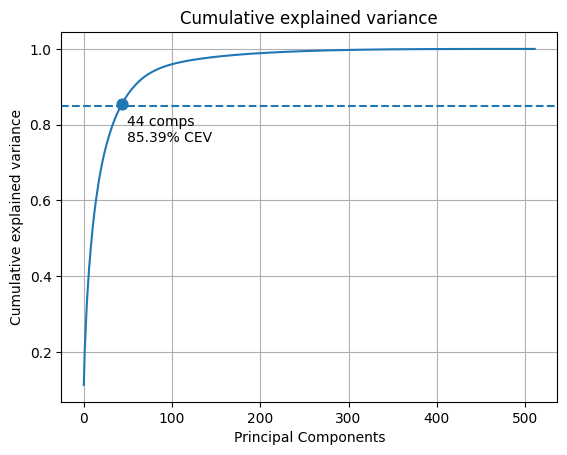

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(E_unit)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# find the first dimension where CEV >= 0.85
target_cev = 0.85
d_85 = int(np.searchsorted(cumulative_variance, target_cev) + 1)  # +1 for "number of components"
cev_85 = cumulative_variance[d_85 - 1]

print(f"Components for 85% CEV: d = {d_85}, CEV = {cev_85:.4f}")

# plot curve and marker
plt.figure()
plt.plot(cumulative_variance, label="CEV")
plt.axhline(target_cev, linestyle="--")  # horizontal line at .85

# point on the curve
plt.scatter([d_85 - 1], [cev_85], s=60)  # x index is d_85-1 because array is 0-based

# optional annotation
plt.annotate(f"{d_85} comps\n{cev_85:.2%} CEV",
             xy=(d_85 - 1, cev_85),
             xytext=(d_85 + 5, cev_85 - 0.1))

plt.title("Cumulative explained variance")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

We get about 90-95% cumulative explained variance at 75 components. about 90 at 58 components, 77 at about 30 components.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=44)
scores_pca = pca.fit_transform(E_unit)

In [ ]:
from sklearn.mixture import GaussianMixture

SEED = 13
X = scores_pca
# Define parameter grids to sweep over
n_components_range = range(1, 31)
covariance_types = ['spherical', 'tied', 'diag', 'full']

# Store AIC and BIC scores
aic_scores = []
bic_scores = []
best_aic_model = None
best_bic_model = None
min_aic = np.inf
min_bic = np.inf

# Perform model sweep
for cov_type in covariance_types:
    for n_components in n_components_range:
        # Initialize GMM model
        gmm = GaussianMixture(n_components=n_components, covariance_type=cov_type, random_state=SEED)

        # Fit model to the data
        gmm.fit(X)

        # Calculate AIC and BIC
        aic = gmm.aic(X)
        bic = gmm.bic(X)

        # Store scores
        aic_scores.append((n_components, cov_type, aic))
        bic_scores.append((n_components, cov_type, bic))

        # Check for best models
        if aic < min_aic:
            min_aic = aic
            best_aic_model = gmm

        if bic < min_bic:
            min_bic = bic
            best_bic_model = gmm

# Best models stored in best_aic_model and best_bic_model
print(f"Best AIC model has {best_aic_model.n_components} components and {best_aic_model.covariance_type} covariance type with AIC: {min_aic:.2f}")
print(f"Best BIC model has {best_bic_model.n_components} components and {best_bic_model.covariance_type} covariance type with BIC: {min_bic:.2f}")

Best AIC model has 30 components and full covariance type with AIC: -6183636.64
Best BIC model has 26 components and full covariance type with BIC: -5914470.45


In [49]:
from sklearn.mixture import GaussianMixture

SEED = 13
X = scores_pca
# Define parameter grids to sweep over
components = 15
cov_type = 'full'

gmm = GaussianMixture(n_components=components, covariance_type=cov_type, random_state=SEED)

# Fit model to the data
gmm.fit(X)
aic = gmm.aic(X)
bic = gmm.bic(X)

# Best models stored in best_aic_model and best_bic_model
print(f"AIC model has 15 components and full covariance type with AIC: {aic:.2f}")
print(f"BIC model has 15 components and full covariance type with BIC: {bic:.2f}")

AIC model has 15 components and full covariance type with AIC: -5970912.13
BIC model has 15 components and full covariance type with BIC: -5832317.69


#First output with 1-24 output:

Best AIC model has **24** components and **full** covariance type with AIC: -3466971.53

Best BIC model has **24** components and **full** covariance type with BIC: -3360704.48

#First output with 20-40 output:

Best AIC model has **39** components and **full** covariance type with AIC: -3542081.11

Best BIC model has **33** components and **full** covariance type with BIC: -3373940.53

interpreting: We want the lowest non-absolute value of AIC/BIC. Negative values do not mean anything important, the logarithmic component of AIC/BIC can
produce negative values. Not much difference in BIC between 24 and 33 components. Best AIC/BIC is simply choosing the lowest value; the change in AIC/BIC decreases as cluster size grows large. We want to see where it smooths out.

#Changed random state to 13 and got higher values, but pattern should persist.

Best AIC model has 30 components and full covariance type with AIC: -7462573.22

Best BIC model has 28 components and full covariance type with BIC: -7112239.26

In [ ]:
from pathlib import Path
SAVE_DIR = Path('/content/drive/MyDrive/tag-polysemy/gmm')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
import numpy as np, joblib

def to_matrix(triples, covs=covariance_types, ks=n_components_range):
    # triples: list of (k, cov, score)
    mat = {cov: np.full(len(ks), np.nan) for cov in covs}
    for k, cov, val in triples:
        if cov in mat:
            mat[cov][k - ks.start] = val
    # stack rows in cov order
    M = np.vstack([mat[cov] for cov in covs])
    return M

# turn your (k, cov, score) lists into matrices once (same helper you used)
A = to_matrix(aic_scores)   # shape: (len(cov_types), len(k))
B = to_matrix(bic_scores)
ks = np.arange(1, 31)       # list(n_components_range)
covs = np.array(['spherical','tied','diag','full'])

import numpy as np, joblib, time
stamp = time.strftime('%Y%m%d_%H%M%S')

# A (AIC matrix), B (BIC matrix), ks (array), covs (array-like)
# save to drive to skip recompute
np.savez_compressed(
    SAVE_DIR / f"gmm_sweep_{stamp}.npz",
    ks=ks,
    covs=covs,
    AIC=A,
    BIC=B,
    pcaScores=scores_pca
)

# dump model to drive
joblib.dump(best_bic_model, SAVE_DIR / f"gmm_best_bic_{stamp}.joblib")
print("Saved to:", SAVE_DIR)

Saved to: /content/drive/MyDrive/tag-polysemy/gmm


In [ ]:
# save model parameters just in case
np.savez_compressed(
  SAVE_DIR / f"gmm_best_params_{stamp}.npz",
  cov_type=best_bic_model.covariance_type,
  k=best_bic_model.n_components,
  weights=best_bic_model.weights_,
  means=best_bic_model.means_,
  covariances=best_bic_model.covariances_
)

CHECKPOINT: Load saved data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import numpy as np, joblib

SAVE_DIR = Path('/content/drive/MyDrive/tag-polysemy/gmm')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

GMMs can model elliptical clusters because the covariance matrix, which represents the shape, size, and orientation of a cluster, allows for flexible shapes rather than being restricted to the spherical shapes assumed by simpler methods like K-Means. This means GMMs can capture clusters that are stretched, tilted, or have different densities, as the covariance matrix accounts for the relationships between different features.

In [4]:
from pathlib import Path
import numpy as np, joblib

# inspect what's in drive
print("Available NPZs:", [p.name for p in SAVE_DIR.glob("gmm_sweep_*.npz")])
print("Available models:", [p.name for p in SAVE_DIR.glob("gmm_best_bic_*.joblib")])

# pick the most recent file of each type (by modification time)
def latest(glob_pattern: str):
    files = list(SAVE_DIR.glob(glob_pattern))
    if not files:
        raise FileNotFoundError(f"No files matched {glob_pattern} in {SAVE_DIR}")
    return max(files, key=lambda p: p.stat().st_mtime)

npz_path = latest("gmm_sweep_*.npz")
model_path = latest("gmm_best_bic_*.joblib")
print("Using:", npz_path.name, "|", model_path.name)

# Load data
data = np.load(npz_path, allow_pickle=False)  # no pickle needed for plain arrays
A, B = data["AIC"], data["BIC"]
ks = data["ks"]
covs = data["covs"]
scores_pca = data["pcaScores"]

best_bic_model = joblib.load(model_path)
print("Loaded shapes:", A.shape, B.shape, "ks len:", len(ks), "covs:", covs)


Available NPZs: ['gmm_sweep_20251112_020136.npz', 'gmm_sweep_20251118_203555.npz', 'gmm_sweep_20251129_224458.npz']
Available models: ['gmm_best_bic_20251112_020136.joblib', 'gmm_best_bic_20251118_203555.joblib', 'gmm_best_bic_20251129_224458.joblib']
Using: gmm_sweep_20251129_224458.npz | gmm_best_bic_20251129_224458.joblib
Loaded shapes: (4, 30) (4, 30) ks len: 30 covs: ['spherical' 'tied' 'diag' 'full']


# Change below code to represent A and B

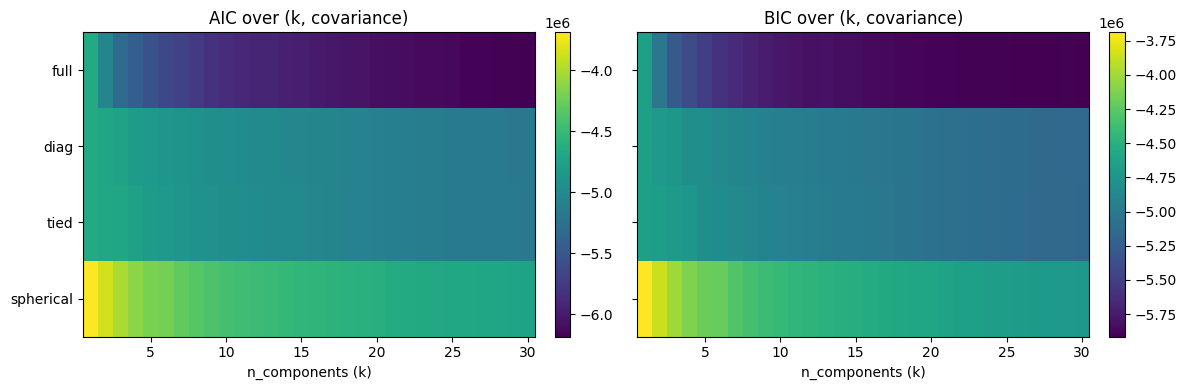

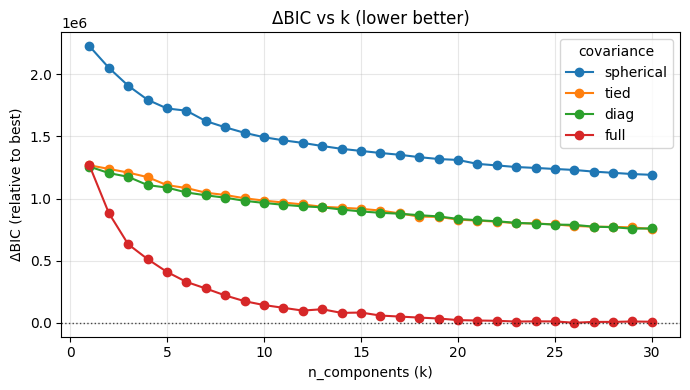

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

SEED = 13
n_components_range = range(1, 31)
covariance_types = ['spherical', 'tied', 'diag', 'full']

# Heatmaps of AIC and BIC across k (n_components) and covariance type
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Iterate through AIC (A) and BIC (B) matrices for plotting
for ax, M, title in zip(axes, [A, B], ["AIC", "BIC"]):
    # Display the matrix as an image (heatmap)
    # aspect='auto' adjusts the aspect ratio to fill the axes
    # origin='lower' sets the (0,0) index of the array to the lower-left corner
    # 'extent' defines the data coordinates that the image spans
    im = ax.imshow(M, aspect='auto', cmap='viridis', origin='lower',
                   extent=[n_components_range.start-0.5, n_components_range.stop-0.5,
                           -0.5, len(covariance_types)-0.5])
    ax.set_title(f'{title} over (k, covariance)')
    ax.set_xlabel('n_components (k)')
    ax.set_yticks(range(len(covariance_types)))
    ax.set_yticklabels(covariance_types)
    # Add a color bar to show the scale of the scores
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# # calculates the difference between each AIC score and the global best AIC score to visualize relative performance
# best_aic = np.nanmin(A)
# fig, ax = plt.subplots(figsize=(7,4))
# for i, cov in enumerate(covariance_types):
#     d = A[i] - best_aic
#     ax.plot(list(n_components_range), d, marker='o', label=cov)
# ax.axhline(10, color='k', ls=':', lw=1, alpha=0.5)
# ax.set_xlabel('n_components (k)')
# ax.set_ylabel('AIC (relative to best)')
# ax.set_title('AIC vs k (lower better)')
# ax.grid(alpha=0.3)
# ax.legend(title='covariance')
# plt.tight_layout()
# plt.show()
# print(best_aic)

# Delta BIC curves: subtract the global best so we can see how decisive it is
# This section calculates the difference between each BIC score and the global best BIC score.
best_bic = np.nanmin(B) # Find the minimum BIC score globally
fig, ax = plt.subplots(figsize=(7,4))
# Iterate through each covariance type to plot its delta BIC curve
for i, cov in enumerate(covariance_types):
    d = B[i] - best_bic # Calculate the difference from the best BIC
    ax.plot(list(n_components_range), d, marker='o', label=cov)
ax.axhline(10, color='k', ls=':', lw=1, alpha=0.7)
ax.set_xlabel('n_components (k)')
ax.set_ylabel('ΔBIC (relative to best)')
ax.set_title('ΔBIC vs k (lower better)')
ax.grid(alpha=0.3)
ax.legend(title='covariance')
plt.tight_layout()
plt.show()

Assignment entropy: Computes the confidence in cluster assignment for each point. Low entropy means that GMM is confident that a point belongs to a specific cluster. The graph shows a sharp peak near 0 with a small tail, indicating that the clusters are well separated.

New UMAP looks different because I changed PCA to 30 instead of 50; a trade-off of 20 components to about 10% of cumulative explained variance.




/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


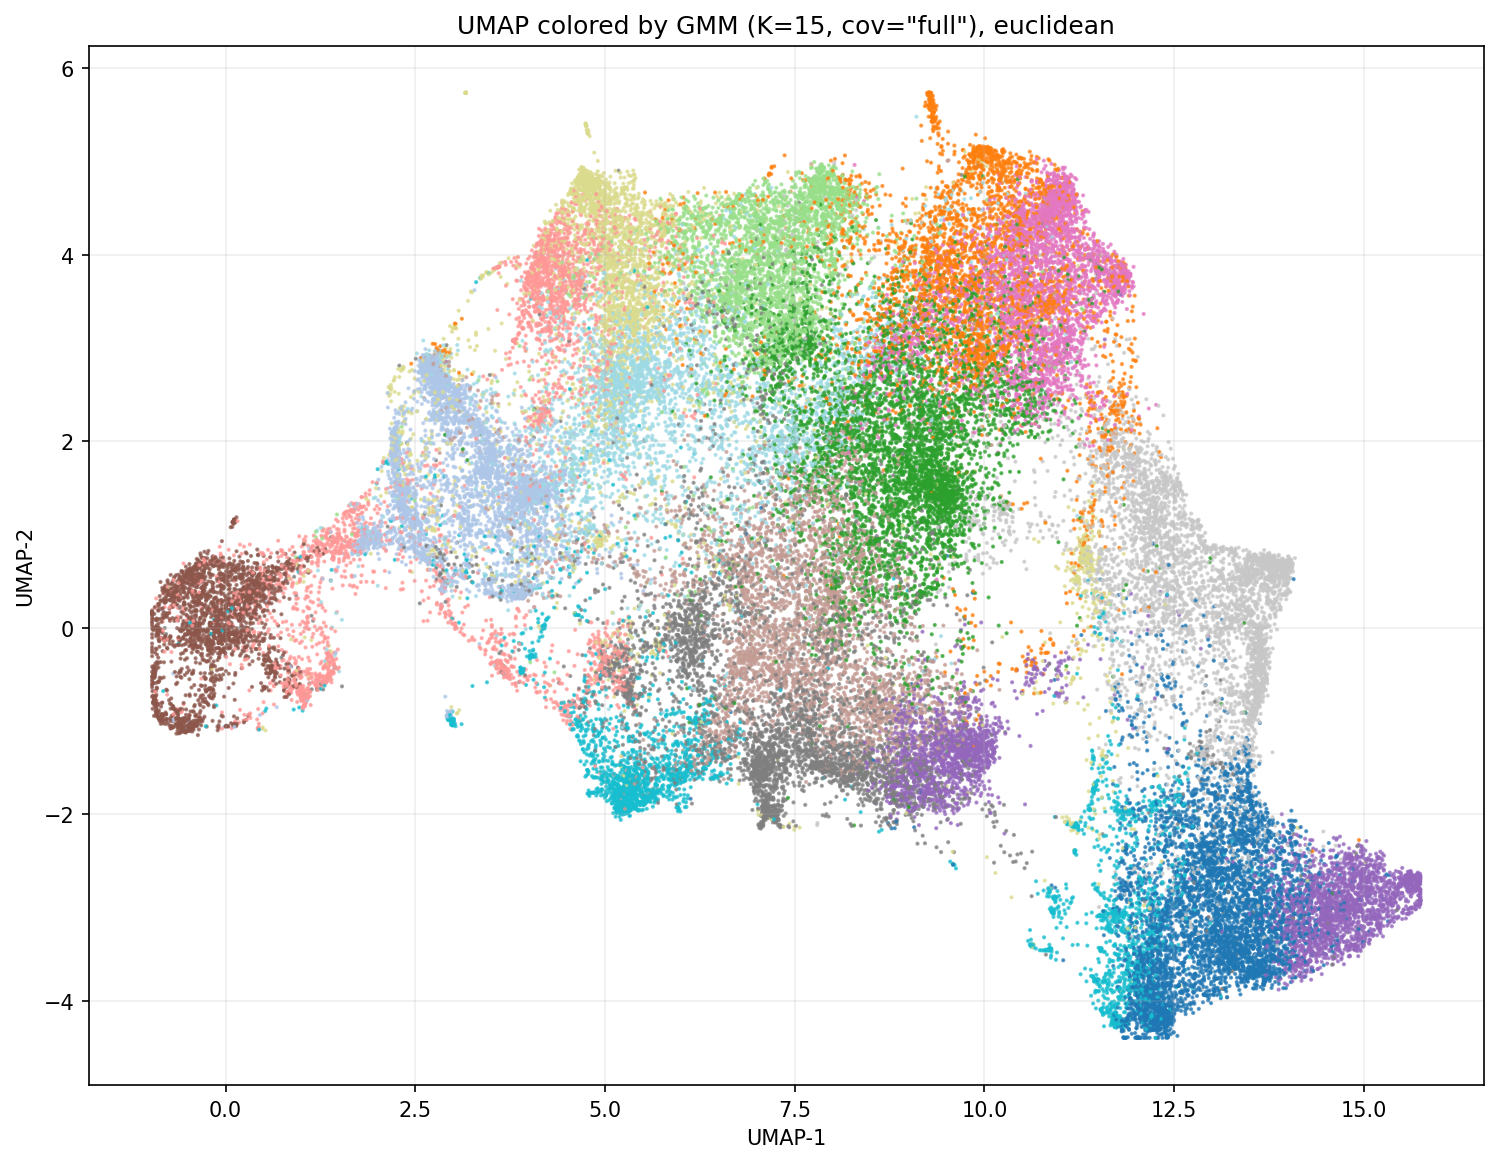

Saved artifacts in: /content/drive/MyDrive/tag-polysemy/clap-embeddings/analysis


In [8]:
# UMAP scatter colored by hard labels, alpha by confidence (soft)
# Uses the BIC-best model fitted on X=scores_pca
import pandas as pd
from sklearn.mixture import GaussianMixture
import umap

SEED = 13

OUT_DIR = Path("/content/drive/MyDrive/tag-polysemy/clap-embeddings/analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

X = scores_pca  # your PCA scores used for GMM selection

gmm = GaussianMixture(n_components=15, covariance_type='full', random_state=SEED)
gmm.fit(X)
aic = gmm.aic(X)
bic = gmm.bic(X)
labels = gmm.predict(X)
proba = gmm.predict_proba(X)
conf = proba.max(axis=1)

# GMM assumes data in PCA space are drawn from Euclidean Gaussians
U = umap.UMAP(metric='cosine', random_state=SEED).fit_transform(X)
xlo, xhi = np.percentile(U[:, 0], [.05, 99.95])
ylo, yhi = np.percentile(U[:, 1], [.05, 99.95])

# clip UMAP outlier coords
U[:,0] = np.clip(U[:,0], xlo, xhi)
U[:,1] = np.clip(U[:,1], ylo, yhi)

plt.figure(figsize=(12, 9), dpi=150)
plt.scatter(U[:,0], U[:,1], c=labels, s=1, cmap='tab20', alpha=.7)
plt.title(f'UMAP colored by GMM (K={gmm.n_components}, cov="{gmm.covariance_type}"), euclidean')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2'); plt.grid(alpha=0.2)
plt.show()

# Save results table for analysis
res_df = pd.DataFrame({
    "track_id": ids,
    "path": paths,
    "cluster": labels,
    "umap_x": U[:, 0],
    "umap_y": U[:, 1],
})
res_df.to_csv(OUT_DIR / f"umap_gmm_pca44_K15cos.csv", index=False)

print("Saved artifacts in:", OUT_DIR)

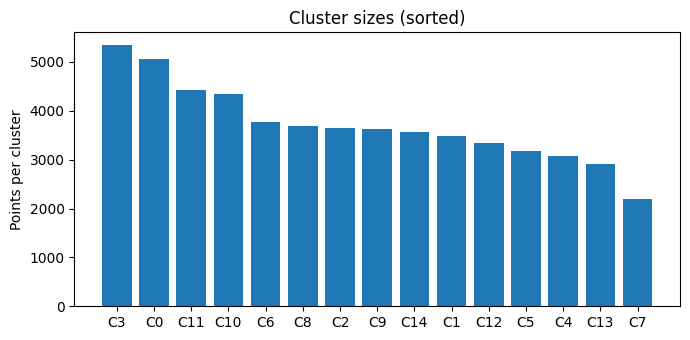

In [9]:
# Cluster size bar chart
counts = np.bincount(labels, minlength=gmm.n_components)
order = np.argsort(counts)[::-1]
plt.figure(figsize=(7,3.5))
plt.bar(range(gmm.n_components), counts[order])
plt.xticks(range(gmm.n_components), [f"C{j}" for j in order])
plt.ylabel('Points per cluster')
plt.title('Cluster sizes (sorted)')
plt.tight_layout()
plt.show()

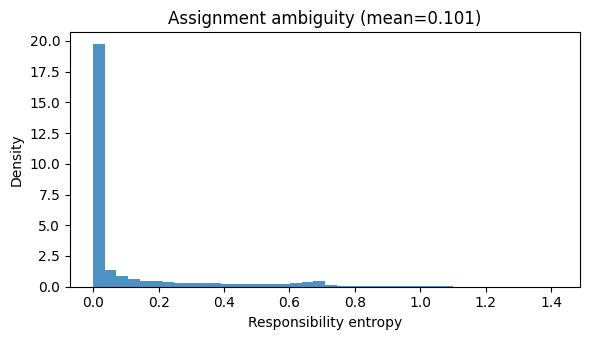

In [11]:
# Responsibility entropy (how overlapped are clusters?)
eps = 1e-12
entropy = -(proba * np.log(proba + eps)).sum(axis=1) # per-point entropy
plt.figure(figsize=(6,3.5))
plt.hist(entropy, bins=40, density=True, alpha=0.8)
plt.xlabel('Responsibility entropy')
plt.ylabel('Density')
plt.title(f'Assignment ambiguity (mean={entropy.mean():.3f})')
plt.tight_layout()
plt.show()

In [12]:
file_path = '/content/drive/MyDrive/tag-polysemy/clap-embeddings/analysis/umap_gmm_pca44_K15.csv'
df = pd.read_csv(file_path)
df.head(5)

,track_id,path,cluster,umap_x,umap_y
0,1100507,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,11,13.097302,-0.014914
1,1129026,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,13,5.124250,-1.726381
2,710586,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,8,7.800599,-0.579605
3,492112,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,11,12.502379,-0.175134
4,1318107,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,12,5.234650,1.201381


In [13]:
!git clone https://github.com/MTG/mtg-jamendo-dataset.git

Cloning into 'mtg-jamendo-dataset'...
remote: Enumerating objects: 1287, done.
remote: Counting objects: 100% (257/257), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 1287 (delta 244), reused 224 (delta 224), pack-reused 1030 (from 1)
Receiving objects: 100% (1287/1287), 42.37 MiB | 31.03 MiB/s, done.
Resolving deltas: 100% (790/790), done.


In [14]:
from pathlib import Path
import pandas as pd

# worked this cell out with LLM, pandas had trouble reading the tsv because there were more
# than 1 tag per song, so pandas expected 6 columns and would receive 7 or 8
# depending on the number of multiple tags.
def read_mtg(relative_path: str, root: str | Path = "mtg-jamendo-dataset") -> pd.DataFrame:
    """
    Minimal reader for MTG-Jamendo TSVs where cols 1–5 are scalars and the rest are TAGS.
    Always skips the first line (header).
    """
    file_path = Path(root) / relative_path
    cols = ["TRACK_ID", "ARTIST_ID", "ALBUM_ID", "PATH", "DURATION", "TAGS"]
    data = []

    with open(file_path, "r", encoding="utf-8") as f:
        next(f, None)  # skip header
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 5:
                continue
            data.append(parts[:5] + ["\t".join(parts[5:])])

    return pd.DataFrame(data, columns=cols)

In [15]:
auto = read_mtg("data/autotagging.tsv")
print(auto.shape)
auto.head(10)

(55609, 6)


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS
0,track_0000214,artist_000014,album_000031,14/214.mp3,124.6,genre---punkrock
1,track_0000215,artist_000014,album_000031,15/215.mp3,151.4,genre---metal
2,track_0000216,artist_000014,album_000031,16/216.mp3,234.9,genre---metal
3,track_0000217,artist_000014,album_000031,17/217.mp3,127.9,genre---punkrock
4,track_0000218,artist_000014,album_000031,18/218.mp3,180.7,genre---punkrock
5,track_0000219,artist_000014,album_000031,19/219.mp3,199.4,genre---metal
6,track_0000220,artist_000014,album_000031,20/220.mp3,174.3,genre---punkrock
7,track_0000221,artist_000014,album_000031,21/221.mp3,224.6,genre---punkrock
8,track_0000222,artist_000014,album_000031,22/222.mp3,161.9,genre---punkrock
9,track_0000223,artist_000014,album_000031,23/223.mp3,217.9,genre---metal


In [16]:
# 1) Make TRACK_ID strings in *both* tables
# If res_df.track_id are integers like 948:
dfc = df.copy()
dfc["TRACK_ID"] = dfc["track_id"].astype(int).map(lambda n: f"track_{n:07d}")  # zero-pad to 7

# (If res_df.track_id are already strings but not padded, coerce similarly.)
# res_df["TRACK_ID"] = (res_df["track_id"].astype(str)
#                       .str.extract(r"(\d+)", expand=False).astype(int)
#                       .map(lambda n: f"track_{n:07d}"))

# 2) Now a straightforward left-merge
cols = ["TRACK_ID", "TAGS", "DURATION", "PATH"]
df = (dfc
      .merge(auto[cols], on="TRACK_ID", how="left", indicator=True))

print(df["_merge"].value_counts())  # sanity: most should be "both"
df = df.drop(columns=["_merge"])

_merge
both          55609
left_only        92
right_only        0
Name: count, dtype: int64


In [17]:
import re

# split tags column into list of tags for easier access
def split_tags(s: str):
    if not isinstance(s, str) or not s.strip():
        return []
    # include commas/semicolons
    parts = re.split(r"[\t,;]+", s)
    return [p.strip().lower() for p in parts if p.strip()]

df["tags_list"] = df["TAGS"].apply(split_tags)
df.head(5)

,track_id,path,cluster,umap_x,umap_y,TRACK_ID,TAGS,DURATION,PATH,tags_list
0,1100507,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,11,13.097302,-0.014914,track_1100507,genre---ethnicrock\tgenre---hiphop\tgenre---po...,187.4,07/1100507.mp3,"[genre---ethnicrock, genre---hiphop, genre---p..."
1,1129026,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,13,5.124250,-1.726381,track_1129026,genre---classical\tinstrument---classicalguita...,232.0,26/1129026.mp3,"[genre---classical, instrument---classicalguit..."
2,710586,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,8,7.800599,-0.579605,track_0710586,genre---acidjazz\tgenre---ambient\tgenre---chi...,337.4,86/710586.mp3,"[genre---acidjazz, genre---ambient, genre---ch..."
3,492112,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,11,12.502379,-0.175134,track_0492112,genre---electronic,184.1,12/492112.mp3,[genre---electronic]
4,1318107,/content/drive/MyDrive/tag-polysemy/mtg-audio-...,12,5.234650,1.201381,track_1318107,genre---classical\tgenre---orchestral\tgenre--...,210.4,07/1318107.mp3,"[genre---classical, genre---orchestral, genre-..."


In [18]:
df_new = df.drop(['TAGS', 'DURATION', 'PATH', 'path', 'TRACK_ID'], axis=1)
df_new.head(5)

,track_id,cluster,umap_x,umap_y,tags_list
0,1100507,11,13.097302,-0.014914,"[genre---ethnicrock, genre---hiphop, genre---p..."
1,1129026,13,5.124250,-1.726381,"[genre---classical, instrument---classicalguit..."
2,710586,8,7.800599,-0.579605,"[genre---acidjazz, genre---ambient, genre---ch..."
3,492112,11,12.502379,-0.175134,[genre---electronic]
4,1318107,12,5.234650,1.201381,"[genre---classical, genre---orchestral, genre-..."


In [19]:
# After merge with indicator=True:
unmatched = df[df["TAGS"].isna()]
print("Unmatched rows:", len(unmatched))
unmatched[["track_id","TRACK_ID"]].head(10)


Unmatched rows: 92


,track_id,TRACK_ID
136,126207,track_0126207
489,1292156,track_1292156
2318,1222994,track_1222994
2382,1404917,track_1404917
3014,1084715,track_1084715
3993,781635,track_0781635
4563,719797,track_0719797
4934,380614,track_0380614
5153,781638,track_0781638
6099,519767,track_0519767


In [20]:
print(df_new.shape)
df_new = df_new[df_new["tags_list"].apply(lambda x: len(x) > 0)]
print(df_new.shape)

(55701, 5)
(55609, 5)


In [21]:
# explode tags_list so each row is a (track, single tag)
tag_cluster_counts = (
    df_new
      .explode("tags_list") # one row per (track, tag)
      .rename(columns={"tags_list": "tag"})
      .groupby(["tag", "cluster"])
      .size()
      .reset_index(name="count")
)

tag_cluster_counts.head()


,tag,cluster,count
0,genre---60s,0,62
1,genre---60s,1,1
2,genre---60s,2,1
3,genre---60s,3,11
4,genre---60s,6,10


In [22]:
def compute_polysemy_stats(group, k_top=3):
    """
    group: rows for a single tag, with columns ['tag', 'cluster', 'count']
    returns: a Series with polysemy statistics for that tag
    """
    counts = group["count"].to_numpy().astype(float)
    total = counts.sum()
    p = counts / total

    # entropy (natural log); relative ordering is what matters
    H = -(p * np.log(p)).sum()

    # normalized entropy: divide by max possible entropy for this tag
    m = len(p)
    H_norm = H / np.log(m) if m > 1 else 0.0

    # top-1 and top-k mass
    p_sorted = np.sort(p)[::-1] # descending
    top1_mass = p_sorted[0]
    k = min(k_top, len(p_sorted))
    topk_mass = p_sorted[:k].sum()

    return pd.Series({
        "n_tracks": int(total),           # how many track-tag instances
        "n_clusters": len(p),             # how many clusters this tag touches
        "entropy": H,                     # raw entropy
        "entropy_norm": H_norm,           # entropy normalized to [0,1]
        "top1_mass": top1_mass,           # fraction of tag’s tracks in the single most common component
        f"top{k_top}_mass": topk_mass,    # fraction in the top 3 components (or fewer if a tag only hits 1–2 clusters)
    })

# apply to each tag
tag_polysemy = (
    tag_cluster_counts
      .groupby("tag", group_keys=False)
      .apply(compute_polysemy_stats, k_top=3)
      .reset_index()
)

tag_polysemy.head()


/tmp/ipython-input-3845319414.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_polysemy_stats, k_top=3)


,tag,n_tracks,n_clusters,entropy,entropy_norm,top1_mass,top3_mass
0,genre---60s,179.0,11.0,1.846366,0.769994,0.346369,0.692737
1,genre---70s,202.0,13.0,2.172503,0.846997,0.232673,0.584158
2,genre---80s,312.0,15.0,2.396690,0.885024,0.147436,0.407051
3,genre---90s,359.0,15.0,2.323666,0.858059,0.211699,0.509749
4,genre---acidjazz,304.0,14.0,1.893127,0.717350,0.332237,0.756579


In [26]:
# most polysemous tags (high normalized entropy, low top1 mass)
tag_polysemy.sort_values(
    ["entropy_norm", "top1_mass"], ascending=[False, True]
).head(10)

,tag,n_tracks,n_clusters,entropy,entropy_norm,top1_mass,top3_mass
173,mood/theme---melodic,1213.0,15.0,2.592908,0.957482,0.114592,0.317395
153,mood/theme---dream,951.0,15.0,2.565382,0.947317,0.143007,0.357518
183,mood/theme---sad,749.0,15.0,2.538371,0.937343,0.133511,0.368491
75,genre---psychedelic,590.0,15.0,2.532252,0.935083,0.127119,0.349153
171,mood/theme---melancholic,441.0,15.0,2.531720,0.934887,0.131519,0.358277
25,genre---darkwave,282.0,15.0,2.520726,0.930827,0.141844,0.365248
120,instrument---organ,157.0,15.0,2.518016,0.929826,0.159236,0.388535
185,mood/theme---slow,437.0,15.0,2.517001,0.929451,0.121281,0.354691
192,mood/theme---travel,171.0,15.0,2.515931,0.929056,0.175439,0.426901
129,instrument---synthesizer,7496.0,15.0,2.510930,0.927210,0.148746,0.367263


In [46]:

# most "monosemous" tags (low entropy, high top1 mass)
tag_polysemy.sort_values(
    ["entropy_norm", "top1_mass"], ascending=[True, False]
).head(5)

,tag,n_tracks,n_clusters,entropy,entropy_norm,top1_mass,top3_mass
48,genre---hardrock,490.0,12.0,1.098284,0.441982,0.712245,0.875510
77,genre---rap,993.0,15.0,1.273932,0.470424,0.646526,0.869084
76,genre---punkrock,729.0,13.0,1.233492,0.480903,0.668038,0.879287
82,genre---singersongwriter,776.0,15.0,1.372554,0.506842,0.563144,0.864691
46,genre---grunge,375.0,11.0,1.222890,0.509985,0.624000,0.904000


In [39]:
tags_to_plot = {
    "mood": [
        "mood/theme---melodic",
        "mood/theme---trailer",
    ],
    "genre": [
        "genre---psychedelic",
        "genre---hardrock",
    ],
    "instrument": [
        "instrument---synthesizer",
        "instrument---ukulele",
    ],
}

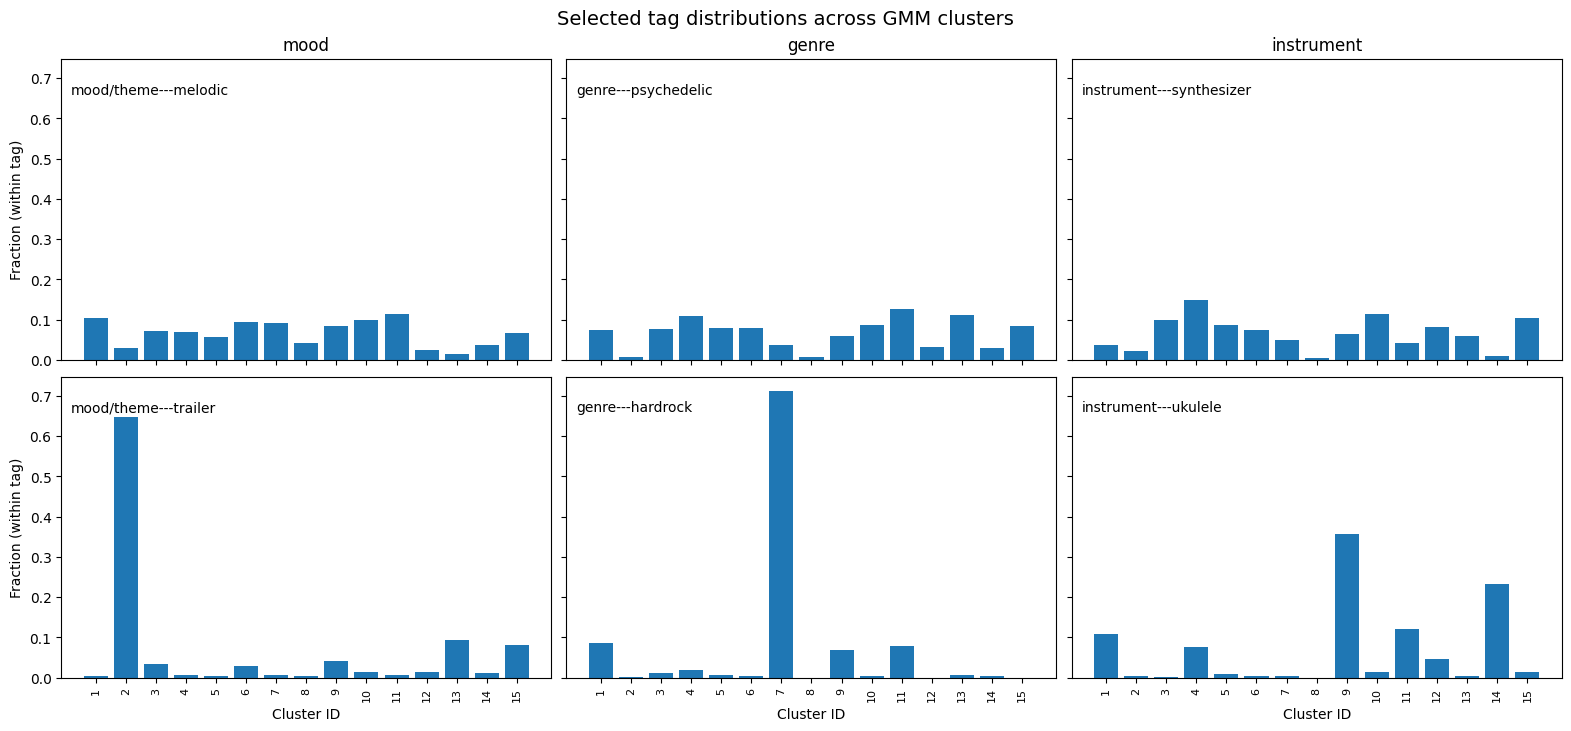

In [45]:
import numpy as np
import matplotlib.pyplot as plt

families_order = ["mood", "genre", "instrument"]
clusters = sorted(df_new["cluster"].unique())

def counts_from_precomputed(tag_cluster_counts, tag, clusters):
    """
    Extracts cluster counts for a specific tag from the precomputed tag_cluster_counts DF.
    re-indexes to ensure all clusters are present, filling missing with 0.
    """
    sub = tag_cluster_counts[tag_cluster_counts["tag"] == tag]
    s = sub.set_index("cluster")["count"].astype(float)
    return s.reindex(clusters, fill_value=0)

def tag_distribution(tag_cluster_counts, tag, clusters, normalize="sum"):
    """
    Computes the distribution of a tag across clusters, optionally normalizing the counts.
    Normalization can be by 'sum' (fractions) or 'max' (scaled to 0-1).
    """
    counts = counts_from_precomputed(tag_cluster_counts, tag, clusters)
    if normalize == "sum":
        total = counts.sum()
        return counts / total if total > 0 else counts
    if normalize == "max":
        m = counts.max()
        return counts / m if m > 0 else counts
    return counts

# define layout for the subplots
ncols = 3
nrows = 2

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5.2 * ncols, 3.6 * nrows),
    sharex=True, sharey=True,
    constrained_layout=True
)

# ensure axes is always a 2D array for consistent indexing
axes = np.atleast_2d(axes)

# iterate through each family (column) and tag (row) to plot distributions
for c, fam in enumerate(families_order):
    tags = tags_to_plot[fam]

    for r in range(nrows):
        ax = axes[r, c]

        # if there are fewer tags than rows, turn off the extra subplots
        if r >= len(tags):
            ax.axis("off")
            continue

        tag = tags[r]
        # get normalized counts for the current tag
        counts = tag_distribution(tag_cluster_counts, tag, clusters, normalize="sum") # return fractions to normalize plots
        ax.bar(clusters, counts.values, width=0.8)

        # add column header (family name) to the top row
        if r == 0:
            ax.set_title(f"{fam}", fontsize=12)
        # add tag label to each subplot
        ax.text(0.02, 0.92, tag, transform=ax.transAxes, fontsize=10, va="top")

        # add X-axis label to the bottom row
        if r == nrows - 1:
            ax.set_xlabel("Cluster ID")
        # add Y-axis label to the leftmost column
        if c == 0:
            ax.set_ylabel("Fraction (within tag)")

        # set x-axis ticks and labels
        ax.set_xticks(clusters)
        ax.set_xticklabels([c + 1 for c in clusters]) # display cluster IDs starting from 1
        ax.tick_params(axis="x", labelrotation=90, labelsize=8)
        ax.tick_params(axis="y", labelsize=10)

fig.suptitle("Selected tag distributions across GMM clusters", fontsize=14)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

df = df_new

def plot_tag_highlight(df, tag_query, xlim=None, ylim=None):
    tag = tag_query.strip().lower()
    has_tag = df["tags_list"].apply(lambda ts: tag in ts).values

    Ux, Uy = df["umap_x"].values, df["umap_y"].values

    xlo, xhi = np.percentile(U[:, 0], [.05, 99.95])
    ylo, yhi = np.percentile(U[:, 1], [.05, 99.95])

    # clip outliers
    Ux = np.clip(Ux, xlo, xhi)
    Uy = np.clip(Uy, ylo, yhi)

    fig, ax = plt.subplots(figsize=(12, 9), dpi=150)

    # background (others)
    ax.scatter(Ux[~has_tag], Uy[~has_tag],
               s=2, alpha=0.4, linewidths=0, color="#bdbdbd", rasterized=True, label="others")

    # highlights
    ax.scatter(Ux[has_tag], Uy[has_tag],
               s=2, alpha=0.8, linewidths=0, color="#ed008c", rasterized=True, label=tag_query)

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"UMAP (euclidean) — highlighted tag: {tag_query}")
    plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2'); plt.grid(alpha=0.2)
    ax.legend(loc="lower right", frameon=False, fontsize=9, markerscale=5, handlelength=1.0)
    plt.show()

plot_tag_highlight(df, "genre---electronic")
plot_tag_highlight(df, "genre---soundtrack")
plot_tag_highlight(df, "genre---pop")
plot_tag_highlight(df, "instrument---piano")
plot_tag_highlight(df, "instrument---synthesizer")
plot_tag_highlight(df, "instrument---drums")
plot_tag_highlight(df, "mood/theme---happy")
plot_tag_highlight(df, "mood/theme---film")
plot_tag_highlight(df, "mood/theme---energetic")

Output hidden; open in https://colab.research.google.com to view.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_tag_with_clusters(df, tag_query, xlim=None, ylim=None, n_std=2.0):
    tag = tag_query.strip().lower()
    has_tag = df["tags_list"].apply(lambda ts: tag in ts).values

    Ux, Uy = df["umap_x"].values, df["umap_y"].values

    fig, ax = plt.subplots(figsize=(12, 9), dpi=150, constrained_layout=True)

    # background (others)
    ax.scatter(Ux[~has_tag], Uy[~has_tag],
               s=2, alpha=0.2, linewidths=0, color="#bdbdbd", rasterized=True, label="others")

    # highlights
    ax.scatter(Ux[has_tag], Uy[has_tag],
               s=4, alpha=0.9, linewidths=0, color="#ed008c", rasterized=True, label=tag_query)

    # overlay cluster “footprints” in UMAP space
    if "cluster" in df.columns:
        for k, sub in df.groupby("cluster"):
            if len(sub) < 5:
                continue  # tiny clusters are noisy

            # center in UMAP space
            cx, cy = sub["umap_x"].mean(), sub["umap_y"].mean()

            # covariance in UMAP space
            cov = np.cov(sub[["umap_x", "umap_y"]].values.T)
            vals, vecs = np.linalg.eigh(cov)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]

            # width, height = n_std * sqrt(eigenvalues)
            width, height = 2 * n_std * np.sqrt(vals)
            angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

            ell = Ellipse(xy=(cx, cy), width=width, height=height,
                          angle=angle, edgecolor="black", facecolor="none",
                          linewidth=0.6, alpha=0.4)
            ax.add_patch(ell)

            # label cluster near its center
            ax.text(cx, cy, str(k), fontsize=10, ha="center", va="center")

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"UMAP (euclidean) — tag: {tag_query} with GMM clusters")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower right", frameon=False, fontsize=8, markerscale=4, handlelength=1.0)
    plt.show()

# Example usage:
plot_tag_with_clusters(df, "mood/theme---melodic")
plot_tag_with_clusters(df, "mood/theme---trailer")
plot_tag_with_clusters(df, "genre---psychedelic")
plot_tag_with_clusters(df, "genre---hardrock")
plot_tag_with_clusters(df, "instrument---synthesizer")
plot_tag_with_clusters(df, "instrument---ukulele")


Output hidden; open in https://colab.research.google.com to view.